<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM__day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [ ]:
# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

In [ ]:
# 1. P(both heads)  -> heads == 2
p_both_heads = np.mean(heads == 2)
print(f"P(both heads): {p_both_heads}")

# 2. P(at least one head)  -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print(f"P(at least one head): {p_at_least_one}")

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

sum_to_one = np.isclose(p_0 + p_1 + p_2, 1.0)
print(f"Do they sum to 1?: {sum_to_one}")

P(both heads): 0.24929
P(at least one head): 0.74761
Do they sum to 1?: True


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.334  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.502
P(A | B)  = 0.667
Independent? False


In [ ]:
# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
# Filter the rolls array down to only values less than 4
rolls_under_4 = rolls[rolls < 4]
# Check how many of those remaining elements are odd
p_odd_given_under_4 = np.mean(rolls_under_4 % 2 != 0)
print(f"P(odd | roll < 4): {p_odd_given_under_4:.4f}")

# 2. P(roll < 4)
p_under_4 = np.mean(rolls < 4)
print(f"P(roll < 4): {p_under_4:.4f}")

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = np.mean(rolls % 2 != 0)
# Events are independent if P(A | B) == P(A)
are_independent = np.isclose(p_odd_given_under_4, p_odd_overall, atol=1e-2)

print(f"P(odd) overall: {p_odd_overall:.4f}")
print(f"Are they independent?: {are_independent}")

P(odd | roll < 4): 0.6661
P(roll < 4): 0.4981
P(odd) overall: 0.5003
Are they independent?: False


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.504


In [ ]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

In [ ]:
# Calculate prior for ham since an email is either spam or ham
p_ham = 1.0 - p_spam

# 2. P('free') via total probability
# Formula: P('free') = P('free'|spam)*P(spam) + P('free'|ham)*P(ham)
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free'): {p_free:.4f}")

# 3. Bayes: P(spam | 'free')
# Formula: P(spam|'free') = [P('free'|spam) * P(spam)] / P('free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free'): {p_spam_given_free:.4f}")

P('free'): 0.1600
P(spam | 'free'): 0.7500


In [ ]:
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.301 (true 0.3)
Poisson(4) mean ~ 4.014 (true 4)


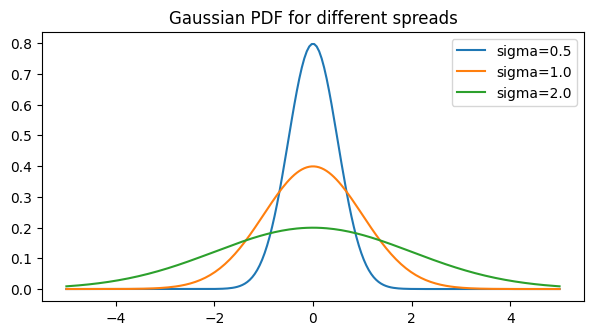

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_759/3821044113.py:21: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Histogram of Poisson Samples ($\mu=2$)')
/tmp/ipykernel_759/3821044113.py:40: SyntaxWarning: invalid escape sequence '\s'
  axes[1].plot(x, pdf_1, label=f'$\sigma = {sigma_1}$ (Narrow/Tall)', color='darkorange', linewidth=2.5)
/tmp/ipykernel_759/3821044113.py:41: SyntaxWarning: invalid escape sequence '\s'
  axes[1].plot(x, pdf_2, label=f'$\sigma = {sigma_2}$ (Wide/Flat)', color='crimson', linewidth=2.5, linestyle='--')
/tmp/ipykernel_759/3821044113.py:43: SyntaxWarning: invalid escape

Poisson Sample Mean (target mu=2): 2.0064


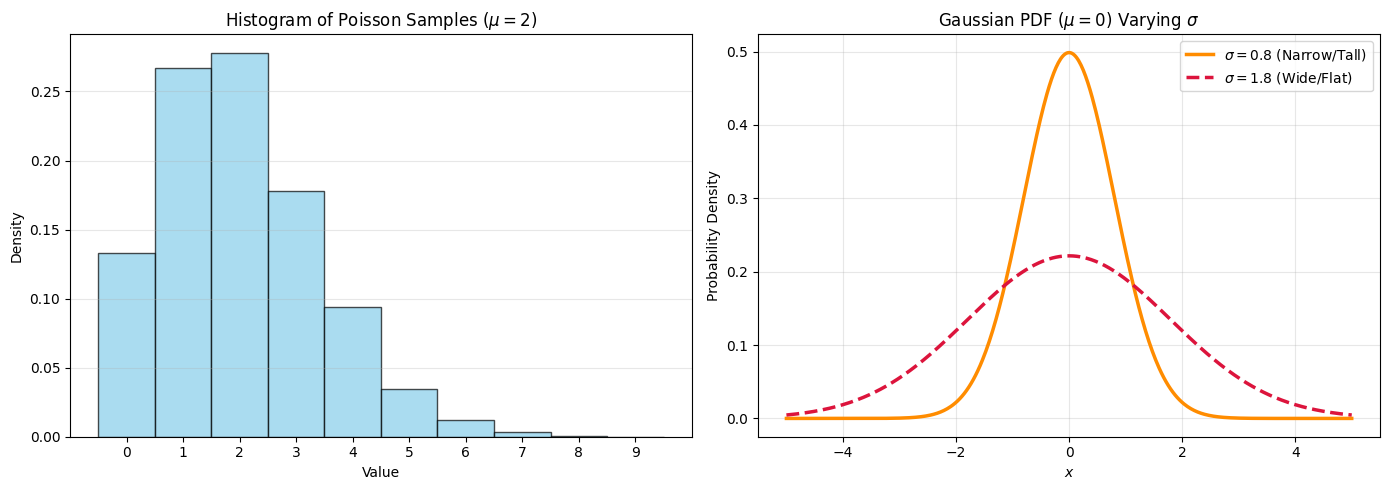

In [ ]:
np.random.seed(42)

# =====================================================================
# 1. Poisson Samples & Mean
# =====================================================================
# Draw 10,000 samples from a Poisson distribution with mu (lambda) = 2
poisson_samples = np.random.poisson(lam=2, size=10000)
sample_mean = np.mean(poisson_samples)

print(f"Poisson Sample Mean (target mu=2): {sample_mean:.4f}")

# =====================================================================
# 2. Plotting the Figures
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Histogram of Poisson Samples ---
# Since Poisson is discrete, we use integer alignment for the bins
bins = np.arange(0, np.max(poisson_samples) + 2) - 0.5
axes[0].hist(poisson_samples, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram of Poisson Samples ($\mu=2$)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_xticks(range(0, np.max(poisson_samples) + 1))
axes[0].grid(axis='y', alpha=0.3)

# --- Chart 2: Gaussian PDF with Different Sigmas ---
x = np.linspace(-5, 5, 500)
mu_gaussian = 0

# Define two different standard deviations (sigmas)
sigma_1 = 0.8
sigma_2 = 1.8

# Generate Gaussian Probability Density Functions
pdf_1 = stats.norm.pdf(x, loc=mu_gaussian, scale=sigma_1)
pdf_2 = stats.norm.pdf(x, loc=mu_gaussian, scale=sigma_2)

# Plot curves
axes[1].plot(x, pdf_1, label=f'$\sigma = {sigma_1}$ (Narrow/Tall)', color='darkorange', linewidth=2.5)
axes[1].plot(x, pdf_2, label=f'$\sigma = {sigma_2}$ (Wide/Flat)', color='crimson', linewidth=2.5, linestyle='--')

axes[1].set_title('Gaussian PDF ($\mu=0$) Varying $\sigma$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('Probability Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Core imports for the whole lab
import pandas as pd
import json

print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:
lifecycle = [
    'Define',    # frame the business problem
    'Collect',   # gather & ingest data
    'Prepare',   # clean & transform
    'Explore',   # EDA & visualise
    'Model',     # train algorithms
    'Evaluate',  # test & validate
    'Deploy',    # serve predictions
    'Monitor',   # watch & maintain  (then loop back!)
]
for i, stage in enumerate(lifecycle, start=1):
    print(f'{i}. {stage}')

1. Define
2. Collect
3. Prepare
4. Explore
5. Model
6. Evaluate
7. Deploy
8. Monitor


In [ ]:
what_happens = {
    'Define':   'turn a business question into an ML problem',
    'Collect':  'pull data from files, databases, APIs',
    'Prepare':  'clean missing values, fix types, engineer features',
    'Explore':  'summarise & visualise to find patterns',
    'Model':    'train and tune algorithms',
    'Evaluate': 'measure performance on unseen data',
    'Deploy':   'put the model into production',
    'Monitor':  'track performance and retrain as needed',
}
for stage, desc in what_happens.items():
    print(f'{stage:9s} -> {desc}')

Define    -> turn a business question into an ML problem
Collect   -> pull data from files, databases, APIs
Prepare   -> clean missing values, fix types, engineer features
Explore   -> summarise & visualise to find patterns
Model     -> train and tune algorithms
Evaluate  -> measure performance on unseen data
Deploy    -> put the model into production
Monitor   -> track performance and retrain as needed


In [ ]:
shuffled = ['Model', 'Define', 'Deploy', 'Collect', 'Monitor',
            'Prepare', 'Evaluate', 'Explore']

In [ ]:
lifecycle = ['Define', 'Collect', 'Prepare', 'Explore', 'Model', 'Evaluate', 'Deploy', 'Monitor']

# 1 & 2. sort 'shuffled' by position in 'lifecycle'
ordered_lifecycle = sorted(shuffled, key=lifecycle.index)

# 3. confirm it matches the reference order
assert ordered_lifecycle == lifecycle
print("Order is correct:", ordered_lifecycle)

Order is correct: ['Define', 'Collect', 'Prepare', 'Explore', 'Model', 'Evaluate', 'Deploy', 'Monitor']


In [ ]:

crisp_dm = [
    'Business Understanding',
    'Data Understanding',
    'Data Preparation',
    'Modeling',
    'Evaluation',
    'Deployment',
]
for i, phase in enumerate(crisp_dm, start=1):
    print(f'{i}. {phase}')

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


In [ ]:
# -----------------------------------------------------------

# Several lifecycle stages can fall under one CRISP-DM phase.
mapping = {
    'Define':   'Business Understanding',
    'Collect':  'Data Understanding',
    'Explore':  'Data Understanding',
    'Prepare':  'Data Preparation',
    'Model':    'Modeling',
    'Evaluate': 'Evaluation',
    'Deploy':   'Deployment',
    'Monitor':  'Deployment',
}
for stage, phase in mapping.items():
    print(f'{stage:9s} -> {phase}')

Define    -> Business Understanding
Collect   -> Data Understanding
Explore   -> Data Understanding
Prepare   -> Data Preparation
Model     -> Modeling
Evaluate  -> Evaluation
Deploy    -> Deployment
Monitor   -> Deployment


Kaggle

In [ ]:
!pip install kaggle kagglehub

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"madhusudhanreddyre","key":"af48494ac4c10a5b49df4456fcc348e8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d heptapod/titanic

Dataset URL: https://www.kaggle.com/datasets/heptapod/titanic
License(s): DbCL-1.0
100% 10.8k/10.8k [00:00<00:00, 21.1MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("titanic.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import pandas as pd

df = pd.read_csv("dataset/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
import kagglehub

path = kagglehub.dataset_download("heptapod/titanic")

print("Dataset downloaded to:", path)

100%|██████████| 10.8k/10.8k [00:00<00:00, 9.19MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/heptapod/titanic/versions/1


In [ ]:
df = pd.read_csv(path + "/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/dataset/train_and_test2.csv")
df.head()


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
import requests
import pandas as pd

url = "https://api.exchangerate-api.com/v4/latest/USD"

response = requests.get(url)
data = response.json()

rates = data["rates"]

df = pd.DataFrame(list(rates.items()), columns=["Currency","Rate"])
df.head()

,Currency,Rate
0,USD,1.00
1,AED,3.67
2,AFN,63.57
3,ALL,82.40
4,AMD,368.41


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("bank.db")

data = {
    "Customer_ID":[1,2,3,4],
    "Loan_Amount":[200000,150000,300000,180000],
    "Credit_Score":[720,680,650,700]
}

df = pd.DataFrame(data)

df.to_sql("customers", conn, if_exists="replace", index=False)

4

In [ ]:
query = "SELECT * FROM customers"

df = pd.read_sql(query, conn)
df.head()

,Customer_ID,Loan_Amount,Credit_Score
0,1,200000,720
1,2,150000,680
2,3,300000,650
3,4,180000,700


In [ ]:
import pandas as pd
import numpy as np

print("--- Intermediate Pandas Exercise ---")
print("Complete each task by writing the requested Pandas code.")
print("------------------------------------")

--- Intermediate Pandas Exercise ---
Complete each task by writing the requested Pandas code.
------------------------------------


In [ ]:
s1_1=[10, 20, 30, 40, 50]

In [ ]:
# 1.2 Create a 3x4 NumPy array named 'np_array1_2' with random integers between 1 and 100
# Note: high=101 is used because the upper bound in np.random.randint is exclusive
np_array1_2 = np.random.randint(1, 101, size=(3, 4))

# 1.3 Convert 'np_array1_2' into a Pandas DataFrame named 'df1_3' with columns 'A', 'B', 'C', 'D'
df1_3 = pd.DataFrame(np_array1_2, columns=['A', 'B', 'C', 'D'])
print(np_array1_2)
print(df1_3)

[[44 30 74 44]
 [27 84 89 73]
 [34 85 24 56]]
    A   B   C   D
0  44  30  74  44
1  27  84  89  73
2  34  85  24  56


In [ ]:
# Task 2: Synthetic Data Generation for Practice
print("\n--- Task 2: Synthetic Data Generation for Practice ---")

# Set random seed for reproducibility (optional)
np.random.seed(42)

# 1. Generate base data fields
# The date range from '2023-01-01' to '2023-04-09' has 99 unique days.
# We sample 100 choices randomly from this range to fill 100 rows.
date_range = pd.date_range(start='2023-01-01', end='2023-04-09')

data = {
    'Date': np.random.choice(date_range, size=100),
    'Region': np.random.choice(['East', 'West', 'North', 'South'], size=100),
    'Product': np.random.choice(['Laptop', 'Mouse', 'Keyboard', 'Monitor'], size=100),
    'Sales': np.random.randint(100, 1001, size=100),  # 1001 makes 1000 inclusive
    'Quantity': np.random.randint(1, 11, size=100)    # 11 makes 10 inclusive
}

# 2. Create the DataFrame
df_sales = pd.DataFrame(data)

# 3. Introduce 5 random NaN values in 'Sales' and 3 random NaN values in 'Quantity'
# np.random.choice(..., replace=False) ensures we pick unique row indices
nan_sales_indices = np.random.choice(df_sales.index, size=5, replace=False)
nan_quantity_indices = np.random.choice(df_sales.index, size=3, replace=False)

# Convert targeted values to float to accept NaN values properly
df_sales['Sales'] = df_sales['Sales'].astype(float)
df_sales['Quantity'] = df_sales['Quantity'].astype(float)

df_sales.loc[nan_sales_indices, 'Sales'] = np.nan
df_sales.loc[nan_quantity_indices, 'Quantity'] = np.nan

print(nan_sales_indices)
print(nan_quantity_indices)


--- Task 2: Synthetic Data Generation for Practice ---
[17 74 43 87  5]
[21 14 47]


In [ ]:
# Task 3: Indexing and Slicing in DataFrames
print("\n--- Task 3: Indexing and Slicing in DataFrames ---")

# 3.1 Select only the 'Region' and 'Sales' columns. Store it in 'df3_1'.
df3_1 = df_sales[['Region', 'Sales']]

# 3.2 Select rows where 'Product' is 'Laptop'. Store it in 'df3_2'.
df3_2 = df_sales[df_sales['Product'] == 'Laptop']

# 3.3 Select rows where 'Region' is 'East' AND 'Sales' are greater than 500. Store it in 'df3_3'.
# Note: Parentheses are mandatory around each individual condition when using bitwise &
df3_3 = df_sales[(df_sales['Region'] == 'East') & (df_sales['Sales'] > 500)]

# 3.4 Select the 'Sales' value for the first entry where 'Product' is 'Monitor'
# First, filter the rows for 'Monitor'
monitor_df = df_sales[df_sales['Product'] == 'Monitor']

# Method using .loc: searches by the DataFrame's index label
# monitor_df.index[0] extracts the original row index of that first Monitor entry
val3_4_loc = df_sales.loc[monitor_df.index[0], 'Sales']

# Method using .iloc: searches strictly by positional integer coordinates
# We look within monitor_df directly: row index 0, and the column index of 'Sales'
sales_col_idx = monitor_df.columns.get_loc('Sales')
val3_4_iloc = monitor_df.iloc[0, sales_col_idx]

# Storing it in 'val3_4' as requested (both methods yield identical values)
val3_4 = val3_4_loc
print(val3_4)
print(val3_4_iloc)
print(val3_4_loc)


--- Task 3: Indexing and Slicing in DataFrames ---
300.0
300.0
300.0


In [ ]:
# Task 5: Data Manipulation (Columns, Sorting, Grouping)
print("\n--- Task 5: Data Manipulation (Columns, Sorting, Grouping) ---")

# 5.1 Create a new column 'Total_Revenue' which is 'Sales' * 'Quantity'.
# Pandas automatically handles element-wise math; any operation involving a NaN results in NaN.
df_sales['Total_Revenue'] = df_sales['Sales'] * df_sales['Quantity']

# 5.2 Sort 'df_sales' by 'Date' in ascending order, then by 'Sales' in descending order.
# Pass lists to both parameters to control individual column sorting behaviors.
df5_2_sorted = df_sales.sort_values(by=['Date', 'Sales'], ascending=[True, False])

# 5.3 Group 'df_sales' by 'Region' and calculate the sum of 'Sales' and 'Quantity' for each region.
# Pass a dictionary to .agg() to apply the sum function specifically to these columns.
df5_3_grouped_region = df_sales.groupby('Region')[['Sales', 'Quantity']].sum()

# 5.4 Group 'df_sales' by 'Product' and find the average 'Sales' for each product.
# By default, Pandas aggregation functions like .mean() skip NaN values automatically.
df5_4_grouped_product = df_sales.groupby('Product')[['Sales']].mean()

print(df_sales)
print(df5_2_sorted)
print(df5_3_grouped_region)
print(df5_4_grouped_product)



--- Task 5: Data Manipulation (Columns, Sorting, Grouping) ---
         Date Region   Product  Sales  Quantity  Total_Revenue
0  2023-02-21  South    Laptop  851.0       7.0         5957.0
1  2023-04-03  South    Laptop  243.0       6.0         1458.0
2  2023-01-15  South     Mouse  708.0       6.0         4248.0
3  2023-03-13   East   Monitor  300.0       6.0         1800.0
4  2023-03-02   East   Monitor  223.0       3.0          669.0
..        ...    ...       ...    ...       ...            ...
95 2023-03-23  South     Mouse  132.0       7.0          924.0
96 2023-02-22   West     Mouse  787.0       8.0         6296.0
97 2023-01-24   West     Mouse  559.0       4.0         2236.0
98 2023-01-26   East  Keyboard  982.0       2.0         1964.0
99 2023-03-30   West  Keyboard  569.0      10.0         5690.0

[100 rows x 6 columns]
         Date Region   Product  Sales  Quantity  Total_Revenue
19 2023-01-02  North    Laptop  919.0       3.0         2757.0
15 2023-01-02  South    Laptop